In [70]:
import matplotlib.pyplot as plt
import numpy as np
import ocha_stratus as stratus
import pandas as pd
from dotenv import load_dotenv
from src.constants import STATE_CONFIG
from src.datasources import glofas, grrr

load_dotenv()

ANALYSIS_START_YEAR = 2003
ANALYSIS_END_YEAR = 2024
WET_MONTHS = [8, 9, 10, 11, 12]
RP_LEVELS = [2, 3, 4, 5]
MAX_LEADTIME = 16

In [71]:
STATE = "Benue"  # or "Benue"
cfg = STATE_CONFIG[STATE]

FIGURES_DIR = "figures"

## Load data

In [72]:
# GloFAS reanalysis (truth)
df_gf_ra = glofas.load_glofas_reanalysis(cfg["glofas_station"])
df_gf_ra["time"] = pd.to_datetime(df_gf_ra["time"])

# GloFAS reforecast (ensemble) — blob path is per-state in STATE_CONFIG
df_gf_rf = stratus.load_parquet_from_blob(cfg["glofas_reforecast_blob"])
df_gf_rf["time"] = pd.to_datetime(df_gf_rf["time"])
df_gf_rf["valid_time"] = pd.to_datetime(df_gf_rf["valid_time"])
df_gf_rf = df_gf_rf[df_gf_rf["leadtime"] <= MAX_LEADTIME]

# Google GRRR reanalysis (truth)
ds_grrr_ra = grrr.load_reanalysis(gauge=cfg["google_gauge"])
df_grrr_ra = grrr.process_reanalysis(ds_grrr_ra)
df_grrr_ra["valid_time"] = pd.to_datetime(df_grrr_ra["valid_time"])

# Google GRRR reforecast
ds_grrr_rf = grrr.load_reforecast(gauge=cfg["google_gauge"])
df_grrr_rf = grrr.process_reforecast(ds_grrr_rf)
df_grrr_rf["valid_time"] = pd.to_datetime(df_grrr_rf["valid_time"])
df_grrr_rf["issue_time"] = pd.to_datetime(df_grrr_rf["issue_time"])
df_grrr_rf = df_grrr_rf[df_grrr_rf["leadtime"] <= MAX_LEADTIME]

/Users/hannahker/Desktop/AA/ds-aa-nga-flooding/src/datasources/grrr.py:22: FutureWarning: In a future version, xarray will not decode the variable 'lead_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  return xr.open_zarr(


In [73]:
import calendar

# Effective wet months per model, then take the intersection as the shared analysis window
gf_available_months = sorted(df_gf_rf["valid_time"].dt.month.unique())
grrr_available_months = sorted(df_grrr_rf["valid_time"].dt.month.unique())

gf_wet_months = sorted(set(WET_MONTHS) & set(gf_available_months))
grrr_wet_months = sorted(set(WET_MONTHS) & set(grrr_available_months))
shared_wet_months = sorted(set(gf_wet_months) & set(grrr_wet_months))
shared_months_str = (
    f"{calendar.month_abbr[shared_wet_months[0]]}–"
    f"{calendar.month_abbr[shared_wet_months[-1]]}"
)

print(f"Shared wet months for all analyses: {shared_wet_months} ({shared_months_str})\n")

for label, avail, wet, df_rf in [
    ("GloFAS",      gf_available_months,   gf_wet_months,   df_gf_rf),
    ("Google GRRR", grrr_available_months, grrr_wet_months, df_grrr_rf),
]:
    years = sorted(
        df_rf[df_rf["valid_time"].dt.month.isin(shared_wet_months)]
        ["valid_time"].dt.year.unique()
    )
    print(f"{label}:")
    print(f"  leadtime range       : {int(df_rf['leadtime'].min())}–{int(df_rf['leadtime'].max())} days")
    print(f"  valid_time months    : {avail}")
    print(f"  effective wet months : {wet}")
    print(f"  years with data      : {years[0]}–{years[-1]}  ({len(years)} years)")
    print()

Shared wet months for all analyses: [8, 9, 10, 11, 12] (Aug–Dec)

GloFAS:
  leadtime range       : 1–16 days
  valid_time months    : [np.int32(1), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
  effective wet months : [8, 9, 10, 11, 12]
  years with data      : 2003–2023  (21 years)

Google GRRR:
  leadtime range       : 0–7 days
  valid_time months    : [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
  effective wet months : [8, 9, 10, 11, 12]
  years with data      : 2016–2022  (7 years)



In [74]:
def shade_action_windows(ax):
    """Shade the GloFAS cumulative operational action leadtime window on any leadtime-axis plot."""
    gf_lt = cfg.get("glofas_leadtime_action")
    if gf_lt is not None:
        ax.axvspan(0, gf_lt, facecolor="#007CE0", edgecolor="none", alpha=0.08, zorder=0)

## Return period thresholds

Both derived from reanalysis annual maxima (wet-season, Aug–Dec).

The N-year RP threshold is the discharge (or streamflow) value exceeded by roughly 1-in-N years. A
2-year threshold is exceeded by ~50% of years; a 5-year threshold by ~20%. These are used throughout
the notebook to define "event" conditions for filtering and detection metrics.

In [75]:
# Both models use the shared wet months for consistency
df_gf_ra_wet = df_gf_ra[df_gf_ra["time"].dt.month.isin(shared_wet_months)]
gf_ra_annual = (
    df_gf_ra_wet.assign(year=df_gf_ra_wet["time"].dt.year)
    .groupby("year")["dis24"].max()
)
gf_thresholds = {rp: gf_ra_annual.quantile(1 - 1 / rp) for rp in RP_LEVELS}

df_grrr_ra_wet = df_grrr_ra[df_grrr_ra["valid_time"].dt.month.isin(shared_wet_months)]
grrr_ra_annual = (
    df_grrr_ra_wet.assign(year=df_grrr_ra_wet["valid_time"].dt.year)
    .groupby("year")["streamflow"].max()
)
google_thresholds = {rp: grrr_ra_annual.quantile(1 - 1 / rp) for rp in RP_LEVELS}

for label, thresholds in [("GloFAS", gf_thresholds), ("Google GRRR", google_thresholds)]:
    print(f"{label} RP thresholds (m³/s):")
    for rp, val in thresholds.items():
        print(f"  {rp}-year: {val:,.0f}")

GloFAS RP thresholds (m³/s):
  2-year: 11,151
  3-year: 12,679
  4-year: 12,928
  5-year: 13,303
Google GRRR RP thresholds (m³/s):
  2-year: 2,583
  3-year: 2,886
  4-year: 3,068
  5-year: 3,087


## Skill and bias vs. leadtime

Metrics computed over all wet-season days (Aug–Dec), across the full analysis period.

- **Spearman ρ**: rank correlation between forecast and reanalysis — how well the forecast preserves
  the ordering of high vs. low flow days. Robust to non-linearity and extreme values.
- **MAPE**: mean absolute percentage error per day — average magnitude of forecast error relative to
  observed flow.
- **PBIAS**: `100 × Σ(forecast − observed) / Σ(observed)` — systematic bias. Positive = consistent
  overforecast; negative = consistent underforecast. Unlike MAPE, positive and negative errors cancel,
  so this captures directional bias only.

GloFAS: ensemble mean across members. Google: single deterministic reforecast.

In [76]:
def skill_by_leadtime(df_rf, df_ra, rf_val_col, ra_val_col, ra_time_col="valid_time",
                      wet_months=WET_MONTHS):
    """Spearman r, MAPE, and PBIAS between reforecast and reanalysis, grouped by leadtime."""
    ra_wet = df_ra[
        df_ra[ra_time_col].dt.month.isin(wet_months)
        & df_ra[ra_time_col].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
    ].set_index(ra_time_col)[[ra_val_col]].rename(columns={ra_val_col: "ra"})

    records = []
    for lt, grp in df_rf.groupby("leadtime"):
        grp_wet = grp[
            grp["valid_time"].dt.month.isin(wet_months)
            & grp["valid_time"].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
        ]
        merged = (
            grp_wet.set_index("valid_time")[[rf_val_col]]
            .join(ra_wet, how="inner")
            .dropna()
        )
        if len(merged) < 10:
            continue
        spearman = merged[rf_val_col].corr(merged["ra"], method="spearman")
        pearson = merged[rf_val_col].corr(merged["ra"])
        mape = (100 * (merged[rf_val_col] - merged["ra"]).abs() / merged["ra"].abs()).mean()
        pbias = 100 * (merged[rf_val_col] - merged["ra"]).sum() / merged["ra"].sum()
        records.append({
            "leadtime": lt, "spearman": spearman, "pearson": pearson,
            "mape": mape, "pbias": pbias, "n": len(merged),
        })
    return pd.DataFrame(records).set_index("leadtime")


# GloFAS: ensemble mean per (valid_time, leadtime)
df_gf_rf_mean = (
    df_gf_rf.groupby(["valid_time", "leadtime"])["dis24"]
    .mean()
    .reset_index()
)

skill_gf = skill_by_leadtime(
    df_gf_rf_mean, df_gf_ra, "dis24", "dis24",
    ra_time_col="time", wet_months=shared_wet_months,
)
skill_grrr = skill_by_leadtime(
    df_grrr_rf, df_grrr_ra, "streamflow", "streamflow",
    wet_months=shared_wet_months,
)

print("GloFAS skill:")
print(skill_gf[["spearman", "pearson", "mape", "pbias", "n"]].round(3))
print("\nGoogle GRRR skill:")
print(skill_grrr[["spearman", "pearson", "mape", "pbias", "n"]].round(3))

GloFAS skill:
          spearman  pearson       mape  pbias     n
leadtime                                           
1            0.987    0.983   6.257000  1.240  1560
2            0.982    0.979   7.265000  2.686  1560
3            0.973    0.962   8.838000  2.821  1580
4            0.960    0.951  10.130000  2.408  1560
5            0.951    0.938  11.253000  2.235  1580
6            0.938    0.929  12.350000  1.619  1580
7            0.932    0.916  13.040000  0.924  1580
8            0.929    0.911  13.644000  0.610  1600
9            0.923    0.908  14.363000  0.317  1600
10           0.919    0.898  15.076000 -0.021  1620
11           0.912    0.893  15.900000 -0.434  1600
12           0.909    0.885  16.395000 -0.722  1620
13           0.904    0.880  16.981001 -1.263  1620
14           0.900    0.866  17.629999 -1.772  1620
15           0.900    0.860  18.208000 -1.874  1640
16           0.898    0.860  18.771000 -2.095  1640

Google GRRR skill:
          spearman  pearson   

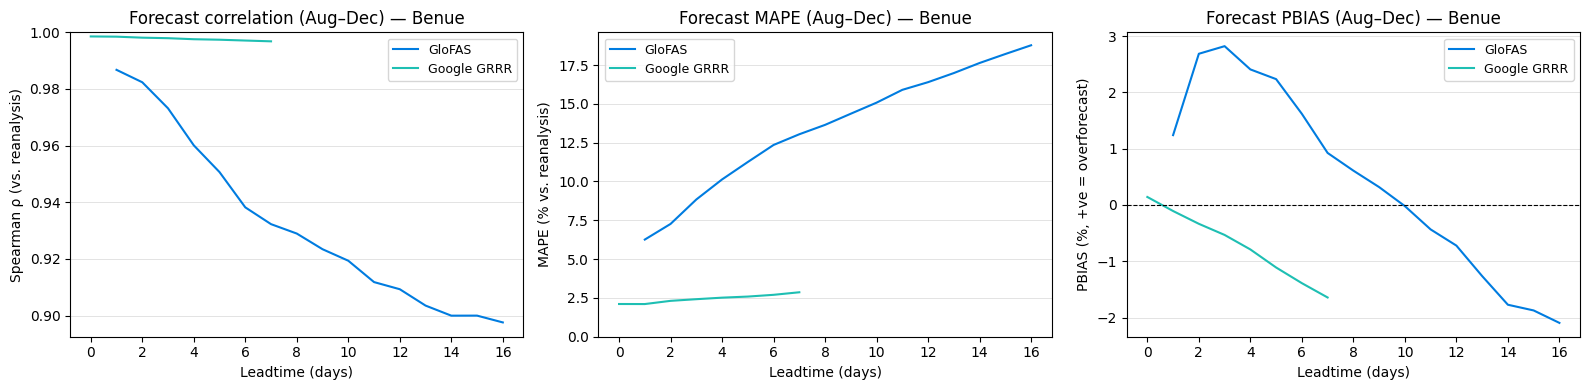

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric, ylabel, ylim in [
    (axes[0], "spearman", "Spearman ρ (vs. reanalysis)", (None, 1)),
    (axes[1], "mape",     "MAPE (% vs. reanalysis)",     (0, None)),
    (axes[2], "pbias",    "PBIAS (%, +ve = overforecast)", (None, None)),
]:
    shade_action_windows(ax)
    if not skill_gf.empty:
        ax.plot(skill_gf.index, skill_gf[metric], color="#007CE0", label="GloFAS")
    if not skill_grrr.empty:
        ax.plot(skill_grrr.index, skill_grrr[metric], color="#1EBFB3", label="Google GRRR")
    ax.set_xlabel("Leadtime (days)")
    ax.set_ylabel(ylabel)
    ax.set_ylim(ylim)
    ax.legend(fontsize=9)
    ax.grid(axis="y", linewidth=0.5, alpha=0.5)

axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[2].axhline(0, color="black", linewidth=0.8, linestyle="--")

axes[0].set_title(f"Forecast correlation ({shared_months_str}) — {STATE}")
axes[1].set_title(f"Forecast MAPE ({shared_months_str}) — {STATE}")
axes[2].set_title(f"Forecast PBIAS ({shared_months_str}) — {STATE}")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{STATE.lower()}_skill_vs_leadtime.png", dpi=200, bbox_inches="tight")
plt.show()

## Conditional skill by return period level

The overall skill above covers all wet-season days. Here, each line restricts to days where the
**reanalysis** (ground truth) exceeded a given RP threshold — i.e. only on genuinely high-flow days.

**How to read it**: if Spearman ρ drops sharply at high RP levels, it means the forecast struggles
most precisely when the river is running dangerously high. PBIAS shows whether the forecast
over- or under-shoots on those days. Comparing across leadtimes reveals how quickly accuracy
degrades as the forecast window grows.

**Caveat — GloFAS issue frequency**: GloFAS reforecasts are issued approximately every 3–4 days
(twice-weekly), whereas Google GRRR is issued daily. This means that at any given leadtime, GloFAS
has roughly one-tenth the number of valid-time entries in the wet season compared to Google. Despite
GloFAS covering a longer historical record (2003–2022 vs 2016–2023 for Google), the effective
sample size for conditional skill is much smaller — typically n=5–15 per RP level for GloFAS vs
n=20–40 for Google. At higher RP levels (4- and 5-year), GloFAS samples can drop to n=5 or fewer,
making the conditional skill estimates highly unstable. Treat GloFAS conditional skill values with
caution, particularly at higher RP levels and longer leadtimes. The annual exceedance detection
and peak bias sections below are better suited to GloFAS's data structure.

In [78]:
COND_RP_LEVELS = [2, 3, 4, 5]
COND_RP_COLORS = {2: "#74ADD1", 3: "#4575B4", 4: "#F46D43", 5: "#D73027"}

gf_cond_thresholds = {rp: gf_ra_annual.quantile(1 - 1 / rp) for rp in COND_RP_LEVELS}
google_cond_thresholds = {rp: grrr_ra_annual.quantile(1 - 1 / rp) for rp in COND_RP_LEVELS}


def conditional_skill_by_rp(df_rf, df_ra, ra_thresholds, rf_val_col, ra_val_col,
                             ra_time_col="valid_time", wet_months=WET_MONTHS):
    """Skill on wet-season days where reanalysis exceeds each RP threshold, by leadtime."""
    ra_full = df_ra[
        df_ra[ra_time_col].dt.month.isin(wet_months)
        & df_ra[ra_time_col].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
    ].set_index(ra_time_col)[[ra_val_col]].rename(columns={ra_val_col: "ra"})

    results = {}
    for rp, thresh in ra_thresholds.items():
        high_flow_idx = ra_full.index[ra_full["ra"] > thresh]
        records = []
        for lt, grp in df_rf.groupby("leadtime"):
            grp_wet = grp[
                grp["valid_time"].dt.month.isin(wet_months)
                & grp["valid_time"].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
            ]
            merged = (
                grp_wet.set_index("valid_time")[[rf_val_col]]
                .join(ra_full, how="inner")
                .loc[lambda d: d.index.isin(high_flow_idx)]
                .dropna()
            )
            if len(merged) < 5:
                continue
            spearman = merged[rf_val_col].corr(merged["ra"], method="spearman")
            pbias = 100 * (merged[rf_val_col] - merged["ra"]).sum() / merged["ra"].sum()
            records.append({"leadtime": lt, "spearman": spearman, "pbias": pbias, "n": len(merged)})
        if records:
            results[rp] = pd.DataFrame(records).set_index("leadtime")
        else:
            results[rp] = pd.DataFrame(columns=["spearman", "pbias", "n"])
    return results


cond_skill_gf = conditional_skill_by_rp(
    df_gf_rf_mean, df_gf_ra, gf_cond_thresholds, "dis24", "dis24",
    ra_time_col="time", wet_months=shared_wet_months,
)
cond_skill_grrr = conditional_skill_by_rp(
    df_grrr_rf, df_grrr_ra, google_cond_thresholds, "streamflow", "streamflow",
    wet_months=shared_wet_months,
)

for model_label, cond_skill in [("GloFAS", cond_skill_gf), ("Google GRRR", cond_skill_grrr)]:
    print(f"{model_label} — sample size (n days) by RP level and leadtime:")
    for rp in COND_RP_LEVELS:
        df = cond_skill.get(rp, pd.DataFrame())
        if df.empty or "n" not in df.columns:
            print(f"  {rp}-yr RP: no data")
        else:
            n_str = "  ".join(f"LT{lt}={int(n)}" for lt, n in df["n"].items())
            print(f"  {rp}-yr RP: {n_str}")
    print()

GloFAS — sample size (n days) by RP level and leadtime:
  2-yr RP: LT1=42  LT2=38  LT3=40  LT4=40  LT5=39  LT6=41  LT7=42  LT8=42  LT9=38  LT10=40  LT11=40  LT12=39  LT13=41  LT14=42  LT15=42  LT16=38
  3-yr RP: LT1=17  LT2=16  LT3=18  LT4=15  LT5=19  LT6=14  LT7=19  LT8=17  LT9=16  LT10=18  LT11=15  LT12=19  LT13=14  LT14=19  LT15=17  LT16=16
  4-yr RP: LT1=15  LT2=13  LT3=17  LT4=11  LT5=16  LT6=12  LT7=16  LT8=15  LT9=13  LT10=17  LT11=11  LT12=16  LT13=12  LT14=16  LT15=15  LT16=13
  5-yr RP: LT1=12  LT2=10  LT3=12  LT4=10  LT5=11  LT6=10  LT7=11  LT8=12  LT9=10  LT10=12  LT11=10  LT12=11  LT13=10  LT14=11  LT15=12  LT16=10

Google GRRR — sample size (n days) by RP level and leadtime:
  2-yr RP: LT0=154  LT1=154  LT2=154  LT3=154  LT4=154  LT5=154  LT6=154  LT7=154
  3-yr RP: LT0=97  LT1=97  LT2=97  LT3=97  LT4=97  LT5=97  LT6=97  LT7=97
  4-yr RP: LT0=80  LT1=80  LT2=80  LT3=80  LT4=80  LT5=80  LT6=80  LT7=80
  5-yr RP: LT0=78  LT1=78  LT2=78  LT3=78  LT4=78  LT5=78  LT6=78  LT7=7

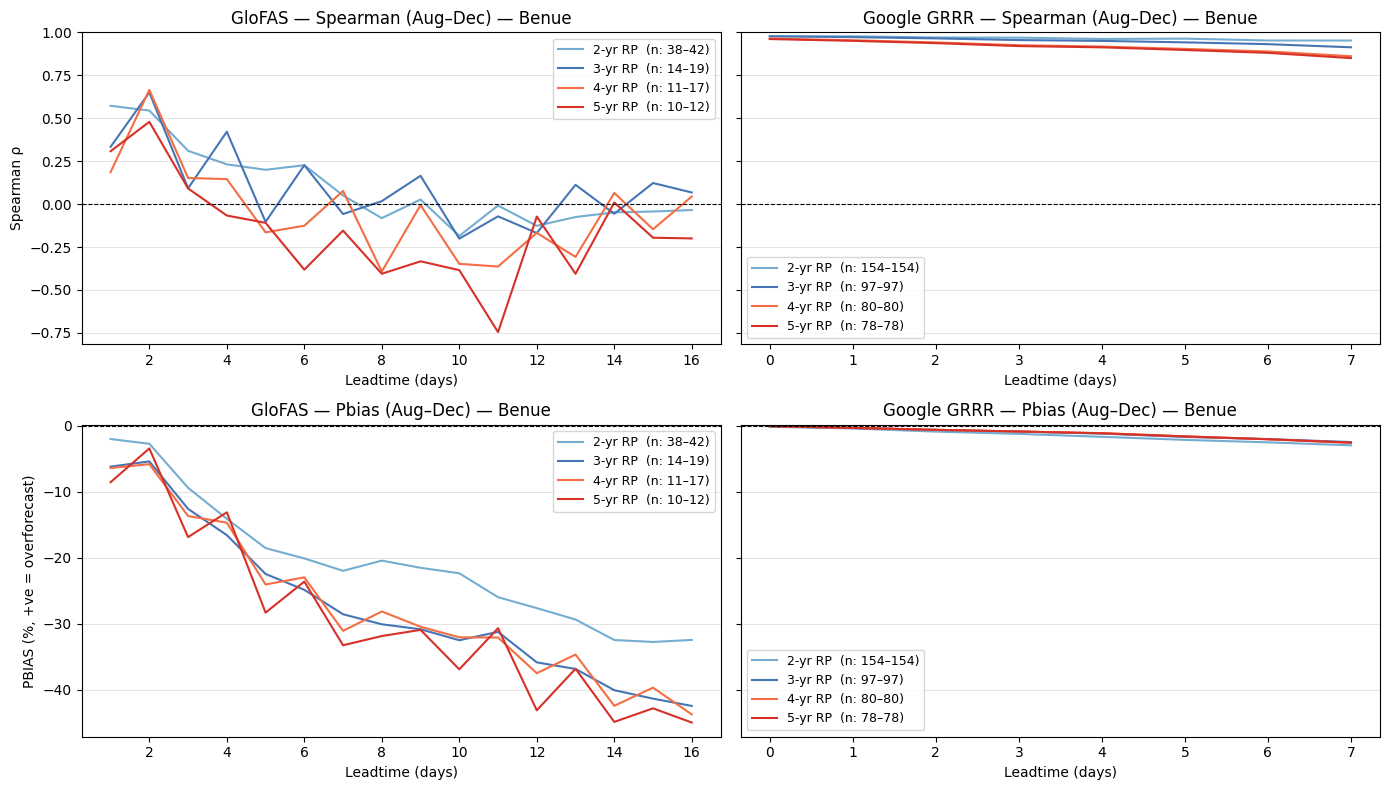

In [79]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey="row")

for col, (model_label, cond_skill) in enumerate([
    ("GloFAS", cond_skill_gf),
    ("Google GRRR", cond_skill_grrr),
]):
    for row, (metric, ylabel, ylim, hline) in enumerate([
        ("spearman", "Spearman ρ", (None, 1), 0),
        ("pbias", "PBIAS (%, +ve = overforecast)", (None, None), 0),
    ]):
        ax = axes[row, col]
        if col == 0:
            shade_action_windows(ax)
        for rp in COND_RP_LEVELS:
            df = cond_skill.get(rp, pd.DataFrame())
            if not df.empty and metric in df.columns:
                n_min = int(df["n"].min())
                n_max = int(df["n"].max())
                label = f"{rp}-yr RP  (n: {n_min}–{n_max})"
                ax.plot(df.index, df[metric], color=COND_RP_COLORS[rp], label=label)
        if hline is not None:
            ax.axhline(hline, color="black", linewidth=0.8, linestyle="--")
        ax.set_xlabel("Leadtime (days)")
        if col == 0:
            ax.set_ylabel(ylabel)
        ax.set_ylim(ylim)
        ax.set_title(f"{model_label} — {metric.replace('_', ' ').title()} ({shared_months_str}) — {STATE}")
        ax.legend(fontsize=9)
        ax.grid(axis="y", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{STATE.lower()}_conditional_skill_by_rp.png", dpi=200, bbox_inches="tight")
plt.show()

## Peak forecast bias at RP levels

Unlike the overall PBIAS above (all wet-season days), this restricts to years when the reanalysis
annual maximum actually exceeded each RP threshold. The question: in flood years, does the forecast
systematically over- or under-predict the peak?

**How to read it**: negative PBIAS means the forecast underestimates peak flows even in major flood
years — the model sees the event but not its full magnitude. This matters for threshold-based
triggers: if the peak is underestimated, the forecast may fall short of the trigger level even when
a real flood is coming.

In [80]:
def peak_bias_at_rp(df_rf, df_ra, ra_thresholds, rf_val_col, ra_val_col,
                    ra_time_col="valid_time", wet_months=WET_MONTHS):
    """PBIAS in annual peak reforecast vs. reanalysis, restricted to event years per RP."""
    ra_wet = df_ra[
        df_ra[ra_time_col].dt.month.isin(wet_months)
        & df_ra[ra_time_col].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
    ]
    ra_annual = ra_wet.assign(year=ra_wet[ra_time_col].dt.year).groupby("year")[ra_val_col].max()

    rf_wet = df_rf[
        df_rf["valid_time"].dt.month.isin(wet_months)
        & df_rf["valid_time"].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
    ].copy()
    rf_wet["year"] = rf_wet["valid_time"].dt.year
    rf_annual = rf_wet.groupby(["year", "leadtime"])[rf_val_col].max().reset_index()

    results = {}
    for rp, thresh in ra_thresholds.items():
        event_years = ra_annual.index[ra_annual > thresh]
        records = []
        for lt, grp in rf_annual.groupby("leadtime"):
            merged = (
                grp.set_index("year")[[rf_val_col]]
                .join(ra_annual.rename("ra"), how="inner")
                .loc[lambda d: d.index.isin(event_years)]
                .dropna()
            )
            if len(merged) < 2:
                continue
            pbias = 100 * (merged[rf_val_col] - merged["ra"]).sum() / merged["ra"].sum()
            records.append({"leadtime": lt, "pbias": pbias, "n_events": len(merged)})
        if records:
            results[rp] = pd.DataFrame(records).set_index("leadtime")
        else:
            results[rp] = pd.DataFrame(columns=["pbias", "n_events"])
    return results


bias_rp_gf = peak_bias_at_rp(
    df_gf_rf_mean, df_gf_ra, gf_thresholds, "dis24", "dis24",
    ra_time_col="time", wet_months=shared_wet_months,
)
bias_rp_grrr = peak_bias_at_rp(
    df_grrr_rf, df_grrr_ra, google_thresholds, "streamflow", "streamflow",
    wet_months=shared_wet_months,
)

for rp in RP_LEVELS:
    print(f"\n--- {rp}-year RP ---")
    if rp in bias_rp_gf and not bias_rp_gf[rp].empty:
        print("GloFAS:")
        print(bias_rp_gf[rp][["pbias", "n_events"]].round(1))
    if rp in bias_rp_grrr and not bias_rp_grrr[rp].empty:
        print("Google GRRR:")
        print(bias_rp_grrr[rp][["pbias", "n_events"]].round(1))


--- 2-year RP ---
GloFAS:
              pbias  n_events
leadtime                     
1         -2.100000         8
2         -4.000000         8
3        -10.900000         8
4        -16.500000         8
5        -20.000000         8
6        -22.100000         8
7        -20.100000         8
8        -16.100000         8
9        -13.300000         8
10       -14.000000         8
11       -13.800000         8
12       -14.700000         8
13       -15.700000         8
14       -18.200001         8
15       -17.799999         8
16       -16.600000         8
Google GRRR:
          pbias  n_events
leadtime                 
0           0.0         5
1          -0.9         5
2          -1.5         5
3          -1.8         5
4          -1.8         5
5          -2.3         5
6          -2.6         5
7          -3.0         5

--- 3-year RP ---
GloFAS:
              pbias  n_events
leadtime                     
1         -0.400000         6
2         -4.300000         6
3         -9.

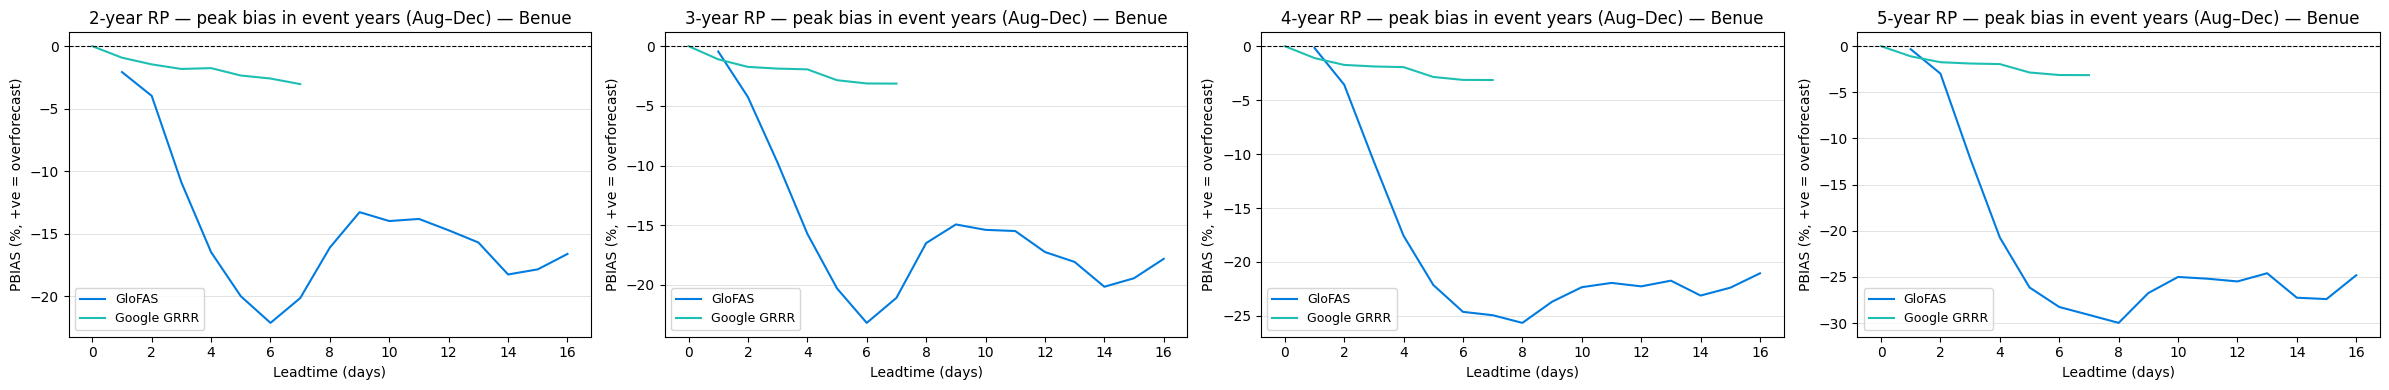

In [81]:
fig, axes = plt.subplots(1, len(RP_LEVELS), figsize=(6 * len(RP_LEVELS), 4))
if len(RP_LEVELS) == 1:
    axes = [axes]

for ax, rp in zip(axes, RP_LEVELS):
    shade_action_windows(ax)
    if rp in bias_rp_gf and not bias_rp_gf[rp].empty:
        ax.plot(bias_rp_gf[rp].index, bias_rp_gf[rp]["pbias"],
                color="#007CE0", label="GloFAS")
    if rp in bias_rp_grrr and not bias_rp_grrr[rp].empty:
        ax.plot(bias_rp_grrr[rp].index, bias_rp_grrr[rp]["pbias"],
                color="#1EBFB3", label="Google GRRR")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Leadtime (days)")
    ax.set_ylabel("PBIAS (%, +ve = overforecast)")
    ax.set_title(f"{rp}-year RP — peak bias in event years ({shared_months_str}) — {STATE}")
    ax.legend(fontsize=9)
    ax.grid(axis="y", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{STATE.lower()}_peak_bias_by_rp.png", dpi=200, bbox_inches="tight")
plt.show()

## Annual exceedance detection by leadtime and RP

Binary detection skill: for each year and leadtime, did any forecast with leadtime ≤ lt predict
an annual wet-season maximum above the RP threshold, and did the reanalysis also exceed it?

Activation is **cumulative**: a year is activated at leadtime lt if any forecast at any leadtime
up to and including lt exceeded the threshold. Each year can activate at most once. This means the
number of activations can only stay the same or increase as leadtime grows.

- **POD** (probability of detection): fraction of actual flood years correctly activated —
  `TP / (TP + FN)`. A value of 1.0 means every flood year was caught.
- **Number of activations**: total years activated — `TP + FP`. Includes both correct activations
  (true flood years) and false alarms (non-flood years).

**Important caveat**: event counts are small (3–10 years depending on RP), so these metrics can
shift significantly with a single misclassified year. Treat them as indicative, not precise
estimates.

In [82]:
def annual_exceedance_detection(df_rf, df_ra, ra_thresholds, rf_val_col, ra_val_col,
                                ra_time_col="valid_time", wet_months=WET_MONTHS):
    """POD and activation count vs. leadtime for each RP threshold.

    Activation is cumulative: at leadtime lt, a year is activated if any forecast
    with leadtime <= lt had an annual wet-season max exceeding the threshold.
    Each year can only activate once. Activation count is therefore monotonically
    non-decreasing as leadtime increases.
    """
    ra_wet = df_ra[
        df_ra[ra_time_col].dt.month.isin(wet_months)
        & df_ra[ra_time_col].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
    ]
    ra_annual = ra_wet.assign(year=ra_wet[ra_time_col].dt.year).groupby("year")[ra_val_col].max()

    rf_wet = df_rf[
        df_rf["valid_time"].dt.month.isin(wet_months)
        & df_rf["valid_time"].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
    ].copy()
    rf_wet["year"] = rf_wet["valid_time"].dt.year

    # Annual max at each (year, leadtime), then cumulative max within each year
    rf_annual = (
        rf_wet.groupby(["year", "leadtime"])[rf_val_col].max()
        .reset_index()
        .sort_values(["year", "leadtime"])
    )
    rf_annual["cum_max"] = rf_annual.groupby("year")[rf_val_col].cummax()

    results = {}
    for rp, thresh in ra_thresholds.items():
        records = []
        for lt, grp in rf_annual.groupby("leadtime"):
            merged = (
                grp.set_index("year")[["cum_max"]]
                .join(ra_annual.rename("ra"), how="inner")
                .dropna()
            )
            n_years = len(merged)
            event = merged["ra"] > thresh
            trigger = merged["cum_max"] > thresh
            tp = int((trigger & event).sum())
            fp = int((trigger & ~event).sum())
            fn = int((~trigger & event).sum())
            tn = int((~trigger & ~event).sum())
            pod = tp / (tp + fn) if (tp + fn) > 0 else np.nan
            far = fp / (tp + fp) if (tp + fp) > 0 else np.nan
            activation_rp = n_years / (tp + fp) if (tp + fp) > 0 else np.nan
            records.append({"leadtime": lt, "pod": pod, "far": far,
                            "activation_rp": activation_rp,
                            "tp": tp, "fp": fp, "fn": fn, "tn": tn})
        results[rp] = pd.DataFrame(records).set_index("leadtime")
    return results


exc_gf = annual_exceedance_detection(
    df_gf_rf_mean, df_gf_ra, gf_thresholds, "dis24", "dis24",
    ra_time_col="time", wet_months=shared_wet_months,
)
exc_grrr = annual_exceedance_detection(
    df_grrr_rf, df_grrr_ra, google_thresholds, "streamflow", "streamflow",
    wet_months=shared_wet_months,
)

for rp in RP_LEVELS:
    print(f"\n--- {rp}-year RP ---")
    if rp in exc_gf:
        print("GloFAS:")
        print(exc_gf[rp][["pod", "far", "activation_rp", "tp", "fp", "fn", "tn"]].round(2))
    if rp in exc_grrr:
        print("Google GRRR:")
        print(exc_grrr[rp][["pod", "far", "activation_rp", "tp", "fp", "fn", "tn"]].round(2))


--- 2-year RP ---
GloFAS:
           pod   far  activation_rp  tp  fp  fn  tn
leadtime                                           
1         0.88  0.00           3.00   7   0   1  13
2         1.00  0.20           2.10   8   2   0  11
3         1.00  0.27           1.91   8   3   0  10
4         1.00  0.27           1.91   8   3   0  10
5         1.00  0.33           1.75   8   4   0   9
6         1.00  0.33           1.75   8   4   0   9
7         1.00  0.38           1.62   8   5   0   8
8         1.00  0.38           1.62   8   5   0   8
9         1.00  0.38           1.62   8   5   0   8
10        1.00  0.38           1.62   8   5   0   8
11        1.00  0.38           1.62   8   5   0   8
12        1.00  0.43           1.50   8   6   0   7
13        1.00  0.47           1.40   8   7   0   6
14        1.00  0.50           1.31   8   8   0   5
15        1.00  0.50           1.31   8   8   0   5
16        1.00  0.56           1.17   8  10   0   3
Google GRRR:
          pod  far  acti

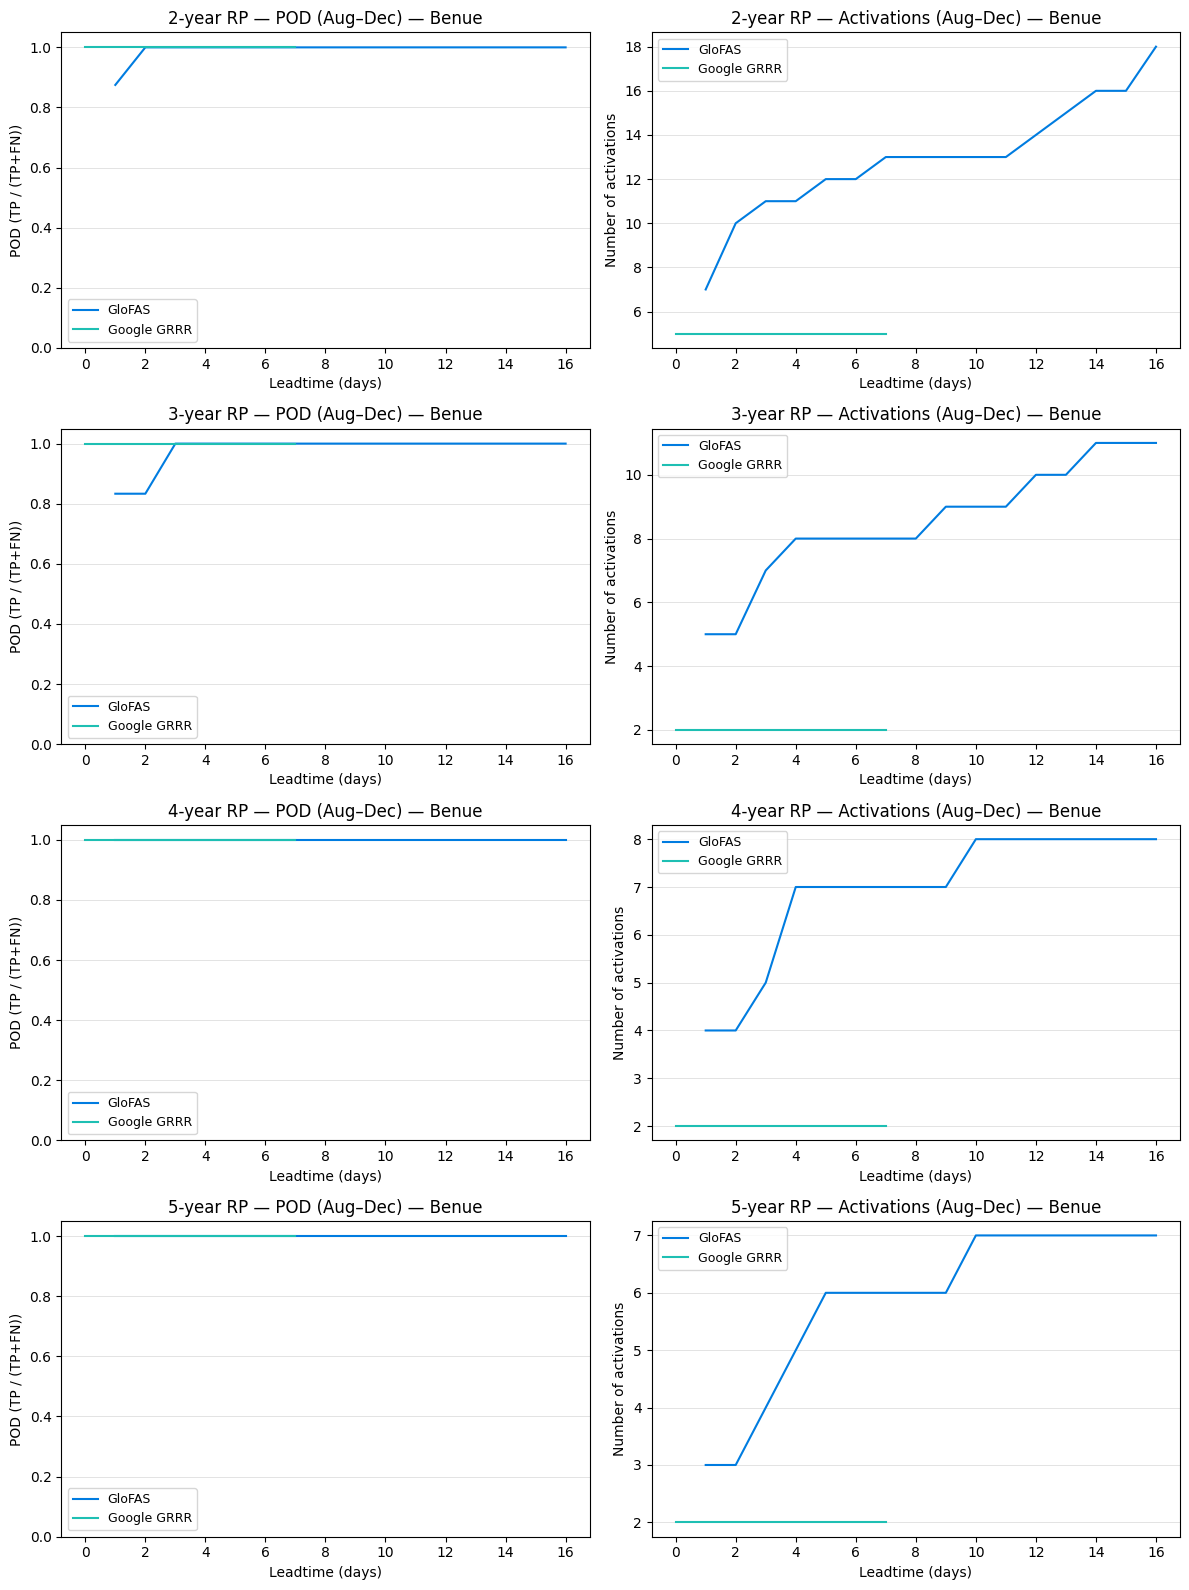

In [83]:
fig, axes = plt.subplots(len(RP_LEVELS), 2, figsize=(12, 4 * len(RP_LEVELS)))
if len(RP_LEVELS) == 1:
    axes = axes[np.newaxis, :]

for row, rp in enumerate(RP_LEVELS):
    ax_pod, ax_act = axes[row, 0], axes[row, 1]
    shade_action_windows(ax_pod)
    shade_action_windows(ax_act)

    for color, label, exc in [
        ("#007CE0", "GloFAS",      exc_gf),
        ("#1EBFB3", "Google GRRR", exc_grrr),
    ]:
        if rp not in exc or exc[rp].empty:
            continue
        df = exc[rp]
        ax_pod.plot(df.index, df["pod"], color=color, label=label)
        ax_act.plot(df.index, df["tp"] + df["fp"], color=color, label=label)

    ax_pod.set_ylim(0, 1.05)
    ax_pod.set_xlabel("Leadtime (days)")
    ax_pod.set_ylabel("POD (TP / (TP+FN))")
    ax_pod.set_title(f"{rp}-year RP — POD ({shared_months_str}) — {STATE}")
    ax_pod.legend(fontsize=9)
    ax_pod.grid(axis="y", linewidth=0.5, alpha=0.5)

    ax_act.set_xlabel("Leadtime (days)")
    ax_act.set_ylabel("Number of activations")
    ax_act.set_title(f"{rp}-year RP — Activations ({shared_months_str}) — {STATE}")
    ax_act.legend(fontsize=9)
    ax_act.grid(axis="y", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{STATE.lower()}_exceedance_by_leadtime.png", dpi=200, bbox_inches="tight")
plt.show()

## Detection at defined trigger thresholds

Hit rate and FAR at the fixed trigger thresholds defined in `constants.py` for this state, rather
than RP-derived thresholds. Uses the same annual exceedance approach: for each year and leadtime,
did the reforecast annual maximum exceed the threshold? Only shown for states where thresholds are
defined.

In [84]:
gf_fixed_thresholds = {}
if cfg["glofas_thresh"] is not None:
    gf_fixed_thresholds["trigger"] = cfg["glofas_thresh"]

google_fixed_thresholds = {}
if cfg["google_thresh"] is not None:
    google_fixed_thresholds["trigger"] = cfg["google_thresh"]

if not gf_fixed_thresholds and not google_fixed_thresholds:
    print(f"No thresholds defined for {STATE} — skipping.")
else:
    exc_gf_fixed = (
        annual_exceedance_detection(
            df_gf_rf_mean, df_gf_ra, gf_fixed_thresholds, "dis24", "dis24",
            ra_time_col="time", wet_months=shared_wet_months,
        )
        if gf_fixed_thresholds else {}
    )
    exc_grrr_fixed = (
        annual_exceedance_detection(
            df_grrr_rf, df_grrr_ra, google_fixed_thresholds, "streamflow", "streamflow",
            wet_months=shared_wet_months,
        )
        if google_fixed_thresholds else {}
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ax_pod, ax_act = axes

    for color, label, exc_fixed, thresh_val in [
        ("#007CE0", "GloFAS",      exc_gf_fixed,   cfg.get("glofas_thresh")),
        ("#1EBFB3", "Google GRRR", exc_grrr_fixed, cfg.get("google_thresh")),
    ]:
        if "trigger" not in exc_fixed or exc_fixed["trigger"].empty:
            continue
        df = exc_fixed["trigger"]
        ax_pod.plot(df.index, df["pod"], color=color, label=f"{label} ({thresh_val:,})")
        ax_act.plot(df.index, df["tp"] + df["fp"], color=color, label=f"{label} ({thresh_val:,})")

    for ax in [ax_pod, ax_act]:
        shade_action_windows(ax)
        ax.set_xlabel("Leadtime (days)")
        ax.legend(fontsize=9)
        ax.grid(axis="y", linewidth=0.5, alpha=0.5)

    ax_pod.set_ylim(0, 1.05)
    ax_pod.set_ylabel("POD (TP / (TP+FN))")
    ax_pod.set_title(f"POD at trigger threshold ({shared_months_str}) — {STATE}")
    ax_act.set_ylabel("Number of activations")
    ax_act.set_title(f"Activations at trigger threshold ({shared_months_str}) — {STATE}")

    plt.tight_layout()
    plt.savefig(
        f"{FIGURES_DIR}/{STATE.lower()}_pod_activations_fixed_thresholds.png",
        dpi=200, bbox_inches="tight",
    )
    plt.show()

No thresholds defined for Benue — skipping.


TypeError: unsupported format string passed to NoneType.__format__

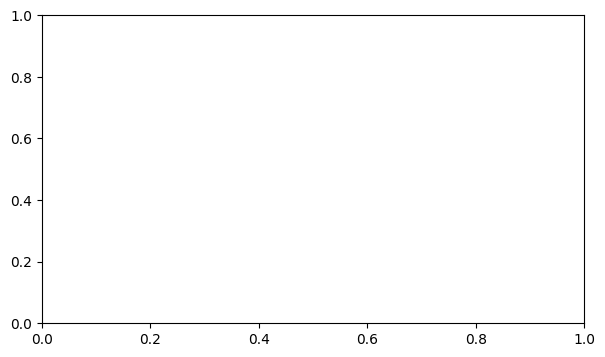

In [85]:
if "exc_gf_fixed" in dir() and "trigger" in exc_gf_fixed and not exc_gf_fixed["trigger"].empty:
    fig, ax1 = plt.subplots(figsize=(7, 4))

    df = exc_gf_fixed["trigger"]
    n_years = df["tp"] + df["fp"] + df["fn"] + df["tn"]
    prob_activation = (df["tp"] + df["fp"]) / n_years

    l1, = ax1.plot(df.index, prob_activation, color="#007CE0",
                   label=f"Prob. of activation ({cfg.get('glofas_thresh'):,})")
    ax1.set_xlabel("Leadtime (days)")
    ax1.set_ylabel("Probability of activation", color="#007CE0")
    ax1.tick_params(axis="y", labelcolor="#007CE0")
    ax1.set_ylim(0, 1.05)

    ax2 = ax1.twinx()
    l2, = ax2.plot(df.index, df["far"], color="#F2645A",
                   label="FAR (FP / (TP+FP))")
    ax2.set_ylabel("False alarm ratio", color="#F2645A")
    ax2.tick_params(axis="y", labelcolor="#F2645A")
    ax2.set_ylim(0, 1.05)

    lines = [l1, l2]
    ax1.legend(lines, [l.get_label() for l in lines], fontsize=9)
    ax1.set_title(f"Activation probability & FAR — GloFAS ({shared_months_str}) — {STATE}")
    ax1.grid(axis="y", linewidth=0.5, alpha=0.5)

    plt.tight_layout()
    plt.savefig(
        f"{FIGURES_DIR}/{STATE.lower()}_prob_activation_fixed_thresholds.png",
        dpi=200, bbox_inches="tight",
    )
    plt.show()

    summary = pd.DataFrame({
        "prob_activation": prob_activation,
        "far": df["far"],
    }).round(2)
    summary.index.name = "leadtime"
    print(summary.to_string())